In [259]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [260]:
df = pd.read_csv('/Users/prachyasumandas/Documents/delivery_time_prediction/Food_Delivery_Times.csv')

In [261]:
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [262]:
df.drop('Order_ID', axis=1, inplace=True)

In [263]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Distance_km             1000 non-null   float64
 1   Weather                 970 non-null    object 
 2   Traffic_Level           970 non-null    object 
 3   Time_of_Day             970 non-null    object 
 4   Vehicle_Type            1000 non-null   object 
 5   Preparation_Time_min    1000 non-null   int64  
 6   Courier_Experience_yrs  970 non-null    float64
 7   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


In [264]:
df.describe()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,970.000000,1000.000000
mean,10.059970,16.982000,4.579381,56.732000
std,5.696656,7.204553,2.914394,22.070915
min,0.590000,5.000000,0.000000,8.000000
25%,5.105000,11.000000,2.000000,41.000000
50%,10.190000,17.000000,5.000000,55.500000
75%,15.017500,23.000000,7.000000,71.000000
max,19.990000,29.000000,9.000000,153.000000


In [265]:
df['Preparation_Time_min'].skew()

0.030008161330597263

creating base model without feature engineering

In [266]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include=np.number).columns

In [267]:
num_cols = num_cols.drop('Delivery_Time_min')

In [268]:
num_cols

Index(['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs'], dtype='object')

In [269]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [270]:
df['Weather'].unique()

array(['Windy', 'Clear', 'Foggy', 'Rainy', 'Snowy', nan], dtype=object)

In [271]:
df['Traffic_Level'].unique()

array(['Low', 'Medium', 'High', nan], dtype=object)

In [272]:
df['Time_of_Day'].unique()

array(['Afternoon', 'Evening', 'Night', 'Morning', nan], dtype=object)

In [273]:
df['Vehicle_Type'].unique()

array(['Scooter', 'Bike', 'Car'], dtype=object)

In [274]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Distance_km             1000 non-null   float64
 1   Weather                 970 non-null    object 
 2   Traffic_Level           970 non-null    object 
 3   Time_of_Day             970 non-null    object 
 4   Vehicle_Type            1000 non-null   object 
 5   Preparation_Time_min    1000 non-null   int64  
 6   Courier_Experience_yrs  970 non-null    float64
 7   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


In [275]:
from sklearn.impute import SimpleImputer

In [276]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [277]:
cat_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [278]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [279]:
from sklearn.model_selection import train_test_split
X = df.drop('Delivery_Time_min', axis=1)
y = df['Delivery_Time_min']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [280]:
from sklearn.linear_model import LinearRegression

In [281]:
model_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',LinearRegression())
])

In [282]:
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

In [283]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'R2 Score: {r2}')

MAE: 6.063414905264767
MSE: 80.14135871539422
R2 Score: 0.8212036240893484


In [284]:
print("Train R2:", model_pipeline.score(X_train, y_train))
print("Test R2:", model_pipeline.score(X_test, y_test))

Train R2: 0.7605897703044278
Test R2: 0.8212036240893484


In [285]:
from sklearn.ensemble import RandomForestRegressor

In [286]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
       
        n_estimators=500,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42


    ))
])

In [287]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [288]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'R2 Score: {r2}')

MAE: 6.723768728202658
MSE: 91.90204127187286
R2 Score: 0.7949653938791327


In [289]:
print("Train R2:", model.score(X_train, y_train))
print("Test R2:", model.score(X_test, y_test))

Train R2: 0.8898534271761267
Test R2: 0.7949653938791327


random forest is overfitting 

our base model is created now we will try to make it even better 

In [290]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Distance_km             1000 non-null   float64
 1   Weather                 970 non-null    object 
 2   Traffic_Level           970 non-null    object 
 3   Time_of_Day             970 non-null    object 
 4   Vehicle_Type            1000 non-null   object 
 5   Preparation_Time_min    1000 non-null   int64  
 6   Courier_Experience_yrs  970 non-null    float64
 7   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


In [291]:
df["Courier_Experience_yrs"].fillna(df["Courier_Experience_yrs"].median(), inplace=True)

/var/folders/rm/hth0y2ld5n7810rnyj1m4bm80000gn/T/ipykernel_2699/1188788207.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Courier_Experience_yrs"].fillna(df["Courier_Experience_yrs"].median(), inplace=True)


In [292]:
df["Weather"].fillna(df["Weather"].mode()[0], inplace=True)
df["Traffic_Level"].fillna(df["Traffic_Level"].mode()[0], inplace=True)
df["Time_of_Day"].fillna(df["Time_of_Day"].mode()[0], inplace=True)

/var/folders/rm/hth0y2ld5n7810rnyj1m4bm80000gn/T/ipykernel_2699/971579208.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Weather"].fillna(df["Weather"].mode()[0], inplace=True)
/var/folders/rm/hth0y2ld5n7810rnyj1m4bm80000gn/T/ipykernel_2699/971579208.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

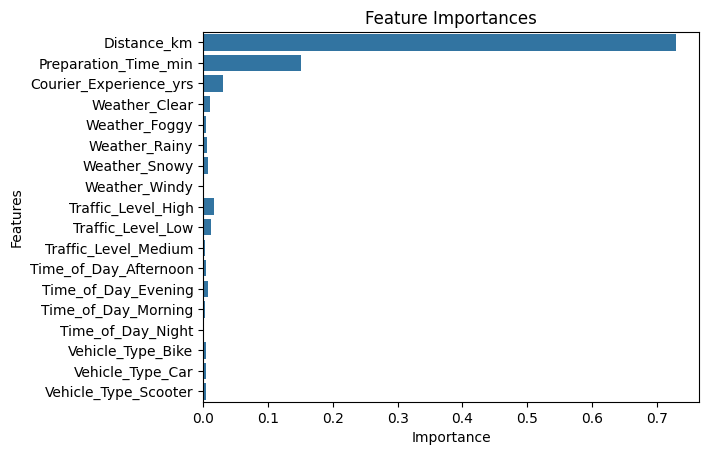

In [293]:
sns.barplot(x=model.named_steps['model'].feature_importances_, y=num_cols.tolist() + model.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(cat_cols).tolist())
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

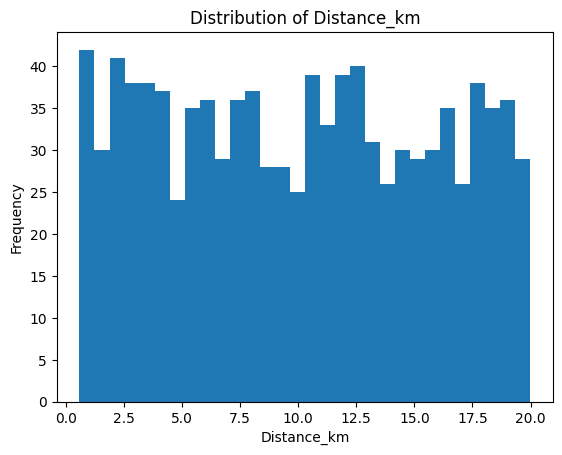

In [294]:
df['Distance_km'].plot(kind='hist', bins=30, title='Distribution of Distance_km')
plt.xlabel('Distance_km')
plt.ylabel('Frequency')
plt.show()

In [295]:
df["Distance_km"].describe()

count    1000.000000
mean       10.059970
std         5.696656
min         0.590000
25%         5.105000
50%        10.190000
75%        15.017500
max        19.990000
Name: Distance_km, dtype: float64

In [296]:
df["distance_experience"] = df["Distance_km"] / (df["Courier_Experience_yrs"] + 1)

In [297]:
df["short_distance"] = (df["Distance_km"] <= 6).astype(int)

df["medium_distance"] = ((df["Distance_km"] > 6) & (df["Distance_km"] <= 11)).astype(int)
df["long_distance"] = (df["Distance_km"] > 11).astype(int)

In [298]:
df["distance_prep_interaction"] = df["Distance_km"] + df["Preparation_Time_min"]

In [299]:
df['Traffic_Level_High'] = (df['Traffic_Level'] == 'High').astype(int)

In [300]:
df["distance_traffic"] = df["Distance_km"] * df["Traffic_Level_High"]

In [301]:
df

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,distance_experience,short_distance,medium_distance,long_distance,distance_prep_interaction,Traffic_Level_High,distance_traffic
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,3.965000,0,1,0,19.93,0,0.00
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84,5.473333,0,0,1,36.42,0,0.00
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59,4.760000,0,1,0,37.52,0,0.00
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,3.720000,0,1,0,12.44,0,0.00
4,19.03,Clear,Low,Morning,Bike,16,5.0,68,3.171667,0,0,1,35.03,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8.50,Clear,High,Evening,Car,13,3.0,54,2.125000,0,1,0,21.50,1,8.50
996,16.28,Rainy,Low,Morning,Scooter,8,9.0,71,1.628000,0,0,1,24.28,0,0.00
997,15.62,Snowy,High,Evening,Scooter,26,2.0,81,5.206667,0,0,1,41.62,1,15.62
998,14.17,Clear,Low,Afternoon,Bike,8,0.0,55,14.170000,0,0,1,22.17,0,0.00


In [302]:
df.columns

Index(['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min', 'distance_experience', 'short_distance',
       'medium_distance', 'long_distance', 'distance_prep_interaction',
       'Traffic_Level_High', 'distance_traffic'],
      dtype='object')

In [303]:
df["Time_of_Day"].value_counts()

Time_of_Day
Morning      338
Evening      293
Afternoon    284
Night         85
Name: count, dtype: int64

In [304]:
df["is_peak_hour"] = df["Time_of_Day"].isin(["Evening", "Night"]).astype(int)

In [305]:
vehicle_speed = {
    "Bike": 1.2,
    "Scooter": 1.0,
    "Bicycle": 0.7
}

df["vehicle_speed_factor"] = df["Vehicle_Type"].map(vehicle_speed)

In [306]:
df["distance_vehicle"] = df["Distance_km"] * df["vehicle_speed_factor"]

In [307]:
df = pd.get_dummies(df, columns=[
    "Weather",
    "Traffic_Level",
    "Time_of_Day",
    "Vehicle_Type"
], drop_first=True)

In [319]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Distance_km                1000 non-null   float64
 1   Preparation_Time_min       1000 non-null   int64  
 2   Courier_Experience_yrs     1000 non-null   float64
 3   Delivery_Time_min          1000 non-null   int64  
 4   distance_experience        1000 non-null   float64
 5   short_distance             1000 non-null   int64  
 6   medium_distance            1000 non-null   int64  
 7   long_distance              1000 non-null   int64  
 8   distance_prep_interaction  1000 non-null   float64
 9   Traffic_Level_High         1000 non-null   int64  
 10  distance_traffic           1000 non-null   float64
 11  is_peak_hour               1000 non-null   int64  
 12  vehicle_speed_factor       1000 non-null   float64
 13  distance_vehicle           1000 non-null   float6

In [318]:
df = df.fillna(df.median(numeric_only=True))

In [320]:
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

In [321]:
df.dtypes

Distance_km                  float64
Preparation_Time_min           int64
Courier_Experience_yrs       float64
Delivery_Time_min              int64
distance_experience          float64
short_distance                 int64
medium_distance                int64
long_distance                  int64
distance_prep_interaction    float64
Traffic_Level_High             int64
distance_traffic             float64
is_peak_hour                   int64
vehicle_speed_factor         float64
distance_vehicle             float64
Weather_Foggy                  int64
Weather_Rainy                  int64
Weather_Snowy                  int64
Weather_Windy                  int64
Traffic_Level_Low              int64
Traffic_Level_Medium           int64
Time_of_Day_Evening            int64
Time_of_Day_Morning            int64
Time_of_Day_Night              int64
Vehicle_Type_Car               int64
Vehicle_Type_Scooter           int64
dtype: object

In [323]:
X = df.drop('Delivery_Time_min', axis=1)
y = df['Delivery_Time_min']

In [324]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [325]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)


In [326]:
r2 = r2_score(y_test, y_pred)
print(f'R2 Score: {r2}')

R2 Score: 0.8228981889180064


In [327]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

In [328]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

In [329]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

In [331]:
random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used h

In [332]:
best_rf = random_search.best_estimator_

In [333]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = best_rf.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.7832153177669254
MAE: 6.944318992785124


In [334]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

In [335]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7, 10],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2, 0.3],
    "min_child_weight": [1, 3, 5]
}

In [336]:
from sklearn.model_selection import RandomizedSearchCV

random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [337]:
random_search_xgb.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... ver

In [338]:
best_xgb = random_search_xgb.best_estimator_

In [339]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = best_xgb.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.7985628247261047
MAE: 6.471937656402588
